In [ ]:
import os

# Core LSD imports
from sclsd.train import LSD
from sclsd.plotting import plot_random_walks

from sclsd.core import LSDConfig
from sclsd.utils import set_all_seeds
from sclsd.utils.seed import clear_pyro_state

# Deep learning
import torch

# Single-cell analysis
import scanpy as sc


print(f"PyTorch version: {torch.__version__}")
print(f"Scanpy version: {sc.__version__}")

/scratch/apour/conda/envs/sclsd/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.4.1+cu121
Scanpy version: 1.11.5


/projects/apour/.cache/tmp/ipykernel_2898903/3031178149.py:20: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"Scanpy version: {sc.__version__}")


In [2]:
# Configure computational device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
SEED = 42
set_all_seeds(SEED)


Using device: cuda


In [3]:
# Load preprocessed adata with prior pseudotime
print("Loading Hematopoiesis dataset...")
data_path = "../../Zenodo/BoneMarrow/preprocessed_adata.h5ad"
adata = sc.read(data_path)


Loading Hematopoiesis dataset...


[LSD] Prior transition matrix set from pseudotime and connectivities.


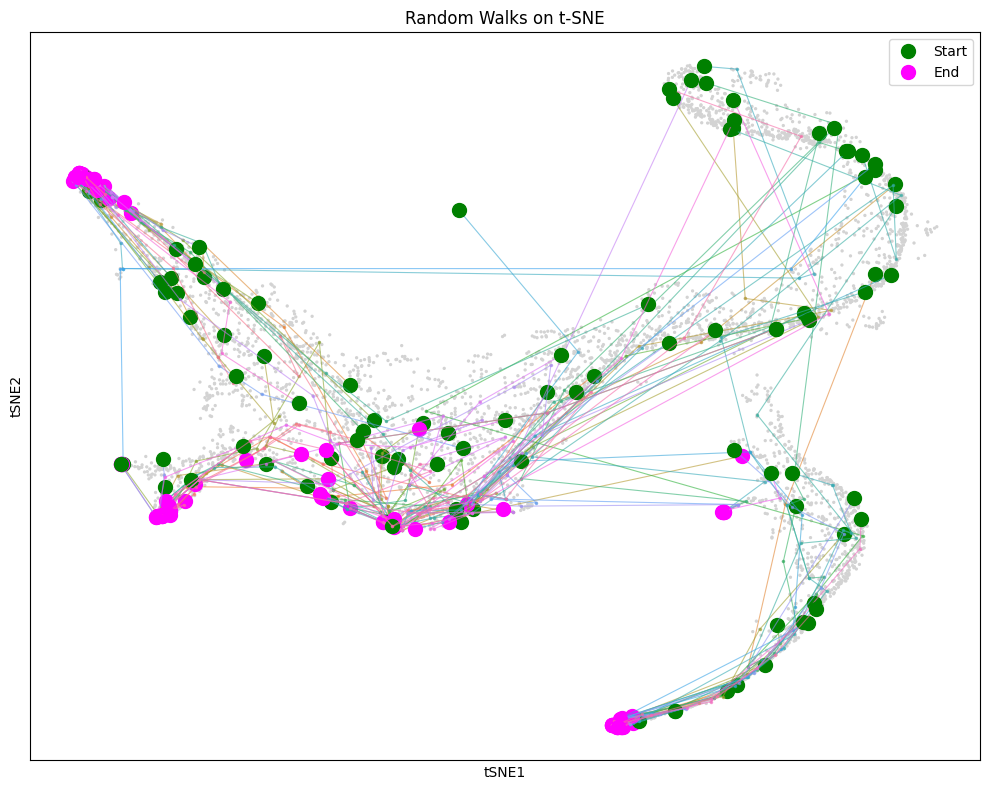

In [4]:
cfg = LSDConfig()

cfg.optimizer.kl_schedule.af = 2
cfg.walks.random_state = SEED

#Initializing LSD model with dataclass config
lsd = LSD(
    adata,
    cfg,
    device=device,
)
#set prior time key
lsd.set_prior_transition(prior_time_key="palantir_pseudotime")
#prepare random walks
lsd.prepare_walks()
#visualize random walks
plot_random_walks(lsd.adata, lsd.walks[:100], "X_tsne") 

Training for 200 epochs


Training Epochs: 100%|██████████| 200/200 [40:19<00:00, 12.10s/it, -ELBO=0.6247, Potential Metric=0.1067, Entropy Metric=0.0348]


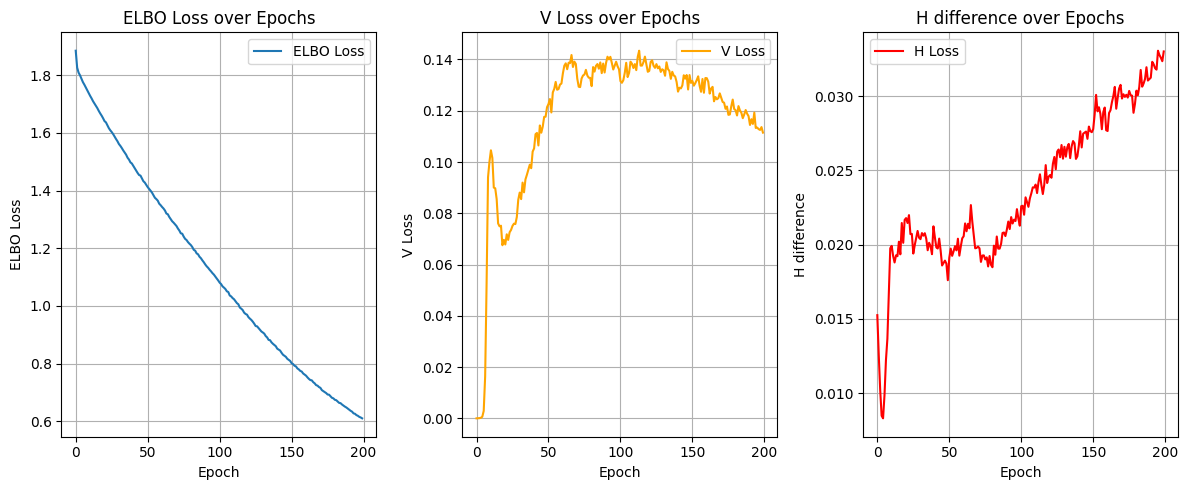


✓ Training completed successfully!


In [5]:
# Define model directory
model_dir = "./model"

# Clear parameter store for fresh training
clear_pyro_state()

# Create save directory
os.makedirs(model_dir, exist_ok=True)
num_epochs = 200
print(f"Training for {num_epochs} epochs")

# Train the model
lsd.train(
    num_epochs=num_epochs,
    save_dir=model_dir,
    save_interval=50,  # Save checkpoints every 20 epochs
    random_state=SEED
)

print("\n" + "="*60)
print("✓ Training completed successfully!")
print("="*60)